# AR(1) on AR(2) — omitted-lag misspecification

A warm-up: the true process is a stationary **AR(2)**,

$$ y_t = \phi_1\,y_{t-1} + \phi_2\,y_{t-2} + \varepsilon_t,\quad \varepsilon_t \sim \mathcal{N}(0,1), $$

and we fit a (misspecified) **AR(1)** by OLS. Yule–Walker on an AR(2)
gives first-order autocorrelation

$$ \rho_1 = \frac{\phi_1}{1-\phi_2}, $$

so the AR(1) pseudo-true coefficient is $\phi^* = \rho_1$. The implied
AR(1) IRF decays geometrically as $(\phi^*)^h$, while the true IRF
follows the AR(2) recursion

$$ \psi_h = \phi_1\,\psi_{h-1} + \phi_2\,\psi_{h-2},\quad \psi_0=1. $$

Picking $(\phi_1,\phi_2)=(0.6,\,0.2)$ keeps the process safely inside
the stationarity triangle and produces a persistent process where the
AR(1) overshoots the impact response and undershoots the long-horizon
tail.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import trange

from mcsim.dgp import ARMASpec, simulate_arma, arma_irf
from mcsim.estimators import fit_ar_ols, ar_irf_from_coefs

sns.set_theme(context="notebook", style="whitegrid")

In [2]:
# Experiment configuration
T        = 1000      # sample length
N_SIMS   = 500       # Monte Carlo replications
HORIZON  = 20        # IRF horizon
PHI1, PHI2 = 0.6, 0.2     # true AR(2) coefficients (stationary)
SEED     = 20260527

true_spec = ARMASpec(ar=(PHI1, PHI2), ma=(), sigma=1.0)
phi_pseudo_true = PHI1 / (1 - PHI2)
print(f"Pseudo-true AR(1) coefficient phi* = {phi_pseudo_true:.4f}")


Pseudo-true AR(1) coefficient phi* = 0.7500


In [4]:
# True IRF of the AR(2) DGP
true_irf = arma_irf(true_spec, HORIZON)
true_irf[:5]


array([1.    , 0.6   , 0.56  , 0.456 , 0.3856])

## Monte Carlo loop

In [5]:
rng = np.random.default_rng(SEED)

phi_hat   = np.empty(N_SIMS)
irf_hat   = np.empty((N_SIMS, HORIZON + 1))

for s in trange(N_SIMS, desc="MC reps"):
    y = simulate_arma(true_spec, T=T, rng=rng)
    phi, _ = fit_ar_ols(y, p=1)
    phi_hat[s] = phi[0]
    irf_hat[s] = ar_irf_from_coefs(phi, HORIZON)


MC reps:   0%|          | 0/500 [00:00<?, ?it/s]

In [6]:
irf_mean = irf_hat.mean(axis=0)
irf_lo, irf_hi = np.percentile(irf_hat, [16, 84], axis=0)

bias = irf_mean - true_irf
rmse = np.sqrt(((irf_hat - true_irf) ** 2).mean(axis=0))

print(f"mean phi_hat  = {phi_hat.mean():.4f}  (pseudo-true = {phi_pseudo_true:.4f})")
print(f"std  phi_hat  = {phi_hat.std(ddof=1):.4f}")


mean phi_hat  = 0.7468  (pseudo-true = 0.7500)
std  phi_hat  = 0.0257


## IRF comparison

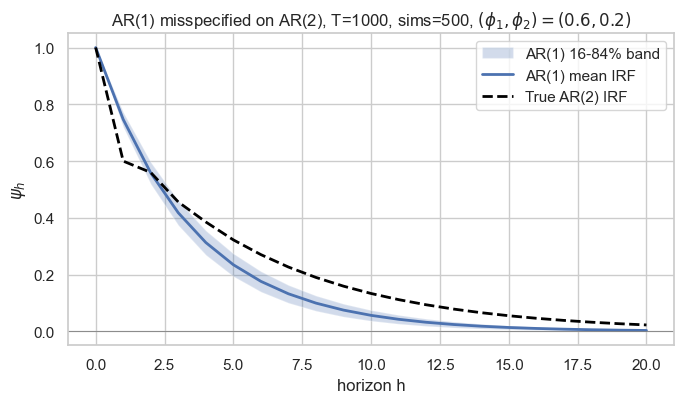

In [7]:
h = np.arange(HORIZON + 1)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.fill_between(h, irf_lo, irf_hi, alpha=0.25, label="AR(1) 16-84% band")
ax.plot(h, irf_mean, lw=2, label="AR(1) mean IRF")
ax.plot(h, true_irf, lw=2, ls="--", color="black", label="True AR(2) IRF")
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("horizon h")
ax.set_ylabel(r"$\psi_h$")
ax.set_title(
    f"AR(1) misspecified on AR(2), T={T}, sims={N_SIMS}, "
    fr"$(\phi_1,\phi_2)=({PHI1},{PHI2})$"
)
ax.legend()
fig.tight_layout()
plt.show()


## Distribution of the AR(1) estimate

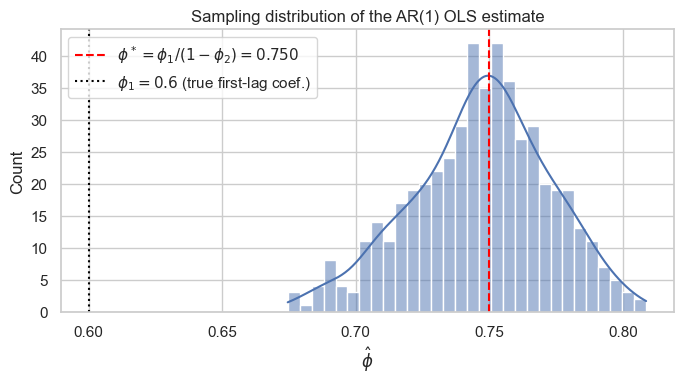

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.0))
sns.histplot(phi_hat, bins=30, kde=True, ax=ax)
ax.axvline(phi_pseudo_true, color="red", ls="--",
           label=fr"$\phi^* = \phi_1/(1-\phi_2) = {phi_pseudo_true:.3f}$")
ax.axvline(PHI1, color="black", ls=":",
           label=fr"$\phi_1 = {PHI1}$ (true first-lag coef.)")
ax.set_xlabel(r"$\hat\phi$")
ax.set_title("Sampling distribution of the AR(1) OLS estimate")
ax.legend()
fig.tight_layout()
plt.show()


## Bias and RMSE by horizon

In [9]:
import pandas as pd

summary = pd.DataFrame({
    "true_irf": true_irf,
    "mean_irf": irf_mean,
    "bias":     bias,
    "rmse":     rmse,
}, index=pd.Index(h, name="horizon"))

summary.head(10)


,true_irf,mean_irf,bias,rmse
horizon,,,,
0,1.000000,1.000000,0.000000,0.000000
1,0.600000,0.746776,0.146776,0.149003
2,0.560000,0.558333,-0.001667,0.038195
3,0.456000,0.417929,-0.038071,0.057152
4,0.385600,0.313192,-0.072408,0.083905
5,0.322560,0.234970,-0.087590,0.096122
6,0.270656,0.176482,-0.094174,0.100661
7,0.226906,0.132699,-0.094207,0.099202
8,0.190275,0.099886,-0.090388,0.094239


### Takeaway

The AR(1) coefficient concentrates around $\phi^* = \phi_1/(1-\phi_2)$,
which is *larger* than the true first-lag coefficient $\phi_1$. So:

- at $h=1$ the AR(1) **overshoots** the true impact ($\phi^* > \phi_1$);
- at large $h$ it **undershoots**, because geometric decay at rate
  $\phi^*$ is faster than the persistence implied by the AR(2)
  characteristic roots.

The qualitative shape (hump vs. monotone decay) and the long-horizon
tail are exactly the kind of features a VAR with the right lag length or
an LP at each horizon should be able to recover — that is the comparison
we'll set up next.
